In [ ]:
from huggingface_hub import snapshot_download
import os

model_id = "meta-llama/Llama-3.2-1B-Instruct"

local_path = snapshot_download(repo_id=model_id)

print("downloaded to:", local_path)
print("files on disk:")
for f in os.listdir(local_path):
    size_mb = os.path.getsize(os.path.join(local_path, f)) / (1024 * 1024)
    print(f"  {f:40s} {size_mb:>10.2f} MB")

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch, psutil, os

model_id = "meta-llama/Llama-3.2-1B-Instruct"

proc = psutil.Process(os.getpid())
ram_before = proc.memory_info().rss / (1024**3)

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16)
model.eval()

ram_after = proc.memory_info().rss / (1024**3)

print(f"RAM before load: {ram_before:.2f} GB")
print(f"RAM after  load: {ram_after:.2f} GB")
print(f"model occupies : {ram_after - ram_before:.2f} GB")
print("model dtype    :", next(model.parameters()).dtype)
print("model device   :", next(model.parameters()).device)

In [ ]:
text = "The capital of France is"
inputs = tokenizer(text, return_tensors="pt")
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask

with torch.no_grad():
    output_ids = model.generate(
        input_ids,
        attention_mask=attention_mask,
        max_new_tokens=1,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

print("========== INPUT ==========")
print("text  :", repr(text))
print("shape :", input_ids.shape)
print("dtype :", input_ids.dtype)
print("ndim  :", input_ids.ndim)
print("===========================")

print()

print("========== OUTPUT ==========")
print("text  :", repr(tokenizer.decode(output_ids[0], skip_special_tokens=True, clean_up_tokenization_spaces=False)))
print("shape :", output_ids.shape)
print("dtype :", output_ids.dtype)
print("ndim  :", output_ids.ndim)
print("============================")

In [ ]:
text = "The capital of France is"
inputs = tokenizer(text, return_tensors="pt")
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask

# ---------- Step 1: LLM (opaque) — outputs a token ID ----------
with torch.no_grad():
    output_ids = model.generate(
        input_ids,
        attention_mask=attention_mask,
        max_new_tokens=1,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

new_token_id = output_ids[0, -1].item()

# ---------- Step 2: decode — inverse vocab lookup ----------
text_piece = tokenizer.decode([new_token_id], clean_up_tokenization_spaces=False)


print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")
print("@                    STEP 1: LLM (opaque)                  @")
print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")

print("========== INPUT ==========")
print("text  :", repr(text))
print("===========================")

print()

print("========== OUTPUT ==========")
print("token ID :", new_token_id)
print("type     :", type(new_token_id).__name__)
print("============================")

print()
print()

print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")
print("@                       STEP 2: decode                     @")
print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")

print("========== INPUT ==========")
print("token ID :", new_token_id)
print("type     :", type(new_token_id).__name__)
print("===========================")

print()

print("========== OUTPUT ==========")
print("text piece :", repr(text_piece))
print("============================")

In [ ]:
from huggingface_hub import snapshot_download, scan_cache_dir
import os
import time
from pathlib import Path

model_id = "meta-llama/Llama-3.2-1B-Instruct"

# --- check cache state BEFORE download ---
def is_cached(model_id):
    try:
        cache_info = scan_cache_dir()
        for repo in cache_info.repos:
            if repo.repo_id == model_id:
                return True, repo.size_on_disk / (1024**2)
        return False, 0
    except Exception:
        return False, 0

cached_before, size_before_mb = is_cached(model_id)

print("┌─ DOWNLOAD STAGE ──────────────────────────────────────────────")
print(f"│ model id          : {model_id}")
print(f"│ cache hit (before): {cached_before}")
if cached_before:
    print(f"│ existing size     : {size_before_mb:.2f} MB")
print("└───────────────────────────────────────────────────────────────")
print()

# --- perform download (or resolve from cache) ---
t0 = time.time()
local_path = snapshot_download(repo_id=model_id)
elapsed = time.time() - t0

print(f"snapshot_download() finished in {elapsed:.2f} s")
print()

# --- cache directory structure ---
local_path_obj = Path(local_path)
hf_cache_root = Path(os.path.expanduser("~/.cache/huggingface/hub"))

print("┌─ CACHE STRUCTURE ─────────────────────────────────────────────")
print(f"│ HF cache root     : {hf_cache_root}")
print(f"│ snapshot path     : {local_path}")
print(f"│ relative to root  : {local_path_obj.relative_to(hf_cache_root)}")
print("└───────────────────────────────────────────────────────────────")
print()

# --- classify each file ---
def categorize(filename):
    name = filename.lower()
    if name.endswith(".safetensors") or name.endswith(".bin"):
        return "weights"
    if name == "config.json" or name == "generation_config.json":
        return "model-config"
    if "tokenizer" in name or name == "special_tokens_map.json":
        return "tokenizer"
    if name.endswith(".md") or name.endswith(".txt"):
        return "metadata/license"
    return "other"

# --- chronological order: HF fetches small files first, weights last ---
# We approximate by sorting by file size ascending (config/tokenizer are small, weights are large)
files = []
for f in os.listdir(local_path):
    full = os.path.join(local_path, f)
    if os.path.isfile(full) or os.path.islink(full):
        size_bytes = os.path.getsize(full)
        files.append((f, size_bytes, categorize(f)))

files_chronological = sorted(files, key=lambda x: x[1])  # small -> large = fetch order

print("┌─ FILES (chronological fetch order: small → large) ────────────")
print(f"│ {'#':<3} {'filename':<40} {'category':<18} {'size':>12}")
print("│" + "─" * 79)
total_bytes = 0
for i, (name, size_bytes, cat) in enumerate(files_chronological, 1):
    size_mb = size_bytes / (1024 * 1024)
    total_bytes += size_bytes
    if size_mb < 1:
        size_str = f"{size_bytes / 1024:.2f} KB"
    else:
        size_str = f"{size_mb:.2f} MB"
    print(f"│ {i:<3} {name:<40} {cat:<18} {size_str:>12}")
print("└───────────────────────────────────────────────────────────────")
print()

total_mb = total_bytes / (1024 * 1024)
total_gb = total_bytes / (1024 ** 3)

print("┌─ DOWNLOAD SUMMARY ────────────────────────────────────────────")
print(f"│ total files       : {len(files)}")
print(f"│ total size        : {total_mb:.2f} MB  ({total_gb:.3f} GB)")
print(f"│ fresh download    : {not cached_before}")
print(f"│ elapsed time      : {elapsed:.2f} s")
print("└───────────────────────────────────────────────────────────────")

In [ ]:
from transformers import AutoTokenizer, AutoConfig, AutoModelForCausalLM
import torch
import psutil
import os
import time

model_id = "meta-llama/Llama-3.2-1B-Instruct"
proc = psutil.Process(os.getpid())

def ram_gb():
    return proc.memory_info().rss / (1024 ** 3)

def fmt_ram(gb):
    return f"{gb:.3f} GB ({gb * 1024:.1f} MB)"

# --- baseline ---
ram_start = ram_gb()
print(f"[step 0] baseline (before any load)")
print(f"         RAM = {fmt_ram(ram_start)}")
print()

# --- step 1: tokenizer ---
print(f"[step 1] loading tokenizer ...")
print(f"         reads: tokenizer.json, tokenizer_config.json, special_tokens_map.json")
t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(model_id)
t_tok = time.time() - t0
ram_after_tok = ram_gb()
print(f"         done in {t_tok:.2f} s")
print(f"         RAM = {fmt_ram(ram_after_tok)}   (Δ +{(ram_after_tok - ram_start)*1024:.1f} MB)")
print(f"         vocab size : {tokenizer.vocab_size}")
print()

# --- step 2: model config ---
print(f"[step 2] loading model config ...")
print(f"         reads: config.json")
t0 = time.time()
config = AutoConfig.from_pretrained(model_id)
t_cfg = time.time() - t0
ram_after_cfg = ram_gb()
print(f"         done in {t_cfg:.2f} s")
print(f"         RAM = {fmt_ram(ram_after_cfg)}   (Δ +{(ram_after_cfg - ram_after_tok)*1024:.1f} MB)")
print(f"         architecture : {config.architectures[0] if config.architectures else 'n/a'}")
print(f"         hidden size  : {config.hidden_size}")
print(f"         num layers   : {config.num_hidden_layers}")
print()

# --- step 3: model weights ---
print(f"[step 3] loading model weights ...")
print(f"         reads: *.safetensors (deserialized into PyTorch tensors)")
t0 = time.time()
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16)
model.eval()
t_mdl = time.time() - t0
ram_after_mdl = ram_gb()
print(f"         done in {t_mdl:.2f} s")
print(f"         RAM = {fmt_ram(ram_after_mdl)}   (Δ +{(ram_after_mdl - ram_after_cfg)*1024:.1f} MB)")
print()

# --- final summary ---
total_params = sum(p.numel() for p in model.parameters())
param_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
param_gb = param_bytes / (1024 ** 3)

print("─" * 65)
print("LOAD SUMMARY")
print("─" * 65)
print(f"  total time           : {t_tok + t_cfg + t_mdl:.2f} s")
print(f"    tokenizer          : {t_tok:.2f} s")
print(f"    config             : {t_cfg:.2f} s")
print(f"    weights            : {t_mdl:.2f} s")
print()
print(f"  RAM growth")
print(f"    baseline           : {fmt_ram(ram_start)}")
print(f"    after tokenizer    : {fmt_ram(ram_after_tok)}  (+{(ram_after_tok - ram_start)*1024:.1f} MB)")
print(f"    after config       : {fmt_ram(ram_after_cfg)}  (+{(ram_after_cfg - ram_after_tok)*1024:.1f} MB)")
print(f"    after weights      : {fmt_ram(ram_after_mdl)}  (+{(ram_after_mdl - ram_after_cfg)*1024:.1f} MB)")
print(f"    total RAM by model : {(ram_after_mdl - ram_start):.3f} GB")
print()
print(f"  model")
print(f"    dtype              : {next(model.parameters()).dtype}")
print(f"    device             : {next(model.parameters()).device}")
print(f"    total parameters   : {total_params:,}  ({total_params / 1e9:.3f} B)")
print(f"    theoretical size   : {param_gb:.3f} GB  (params × dtype bytes)")
print("─" * 65)

In [1]:
import os, time
from pathlib import Path
import torch
import psutil
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display, Markdown

%matplotlib inline

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 10

CATEGORY_COLORS = {
    "weights":          "#d62728",
    "tokenizer":        "#2ca02c",
    "model-config":     "#1f77b4",
    "metadata/license": "#9467bd",
    "other":            "#7f7f7f",
}

PROC = psutil.Process(os.getpid())
def ram_mb(): return PROC.memory_info().rss / (1024 ** 2)

def fmt_size(b):
    if b < 1024:        return f"{b} B"
    if b < 1024**2:     return f"{b/1024:.2f} KB"
    if b < 1024**3:     return f"{b/1024**2:.2f} MB"
    return f"{b/1024**3:.2f} GB"

STAGE_LOG = []

class Stage:
    """Reusable timing + RAM tracker. Use in every level."""
    def __init__(self, name, reads=""):
        self.name, self.reads = name, reads
    def __enter__(self):
        print(f"▶ {self.name}")
        if self.reads: print(f"  reads: {self.reads}")
        self.ram_start = ram_mb()
        self.t_start = time.time()
        return self
    def __exit__(self, *a):
        dt = time.time() - self.t_start
        ram_end = ram_mb()
        delta = ram_end - self.ram_start
        STAGE_LOG.append({
            "stage":         self.name,
            "reads":         self.reads,
            "ram_before_MB": round(self.ram_start, 1),
            "ram_after_MB":  round(ram_end, 1),
            "ram_delta_MB":  round(delta, 1),
            "time_s":        round(dt, 2),
        })
        print(f"  ✓ {dt:.2f}s   ΔRAM +{delta:.1f} MB   total {ram_end:.1f} MB\n")

MODEL_ID = "meta-llama/Llama-3.2-1B-Instruct"

## Part 1 — Download stage

_Where do files land on disk? What is fetched and in what order?_

**Cache before:** hit=`True`, size=`4.61 GB`

▶ snapshot_download
  reads: huggingface hub


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

  ✓ 0.12s   ΔRAM +1.9 MB   total 326.3 MB




**Cache layout**
- root: `/home/ubuntu/.cache/huggingface/hub`
- snapshot: `/home/ubuntu/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/snapshots/9213176726f574b556790deb65791e0c5aa438b6`
- relative: `models--meta-llama--Llama-3.2-1B-Instruct/snapshots/9213176726f574b556790deb65791e0c5aa438b6`


**Files on disk (small → large = fetch order)**

,filename,category,size
#,,,
1,generation_config.json,model-config,189 B
2,special_tokens_map.json,tokenizer,296 B
3,config.json,model-config,877 B
4,.gitattributes,other,1.48 KB
5,USE_POLICY.md,metadata/license,5.88 KB
6,LICENSE.txt,metadata/license,7.53 KB
7,README.md,metadata/license,40.76 KB
8,tokenizer_config.json,tokenizer,53.25 KB
9,tokenizer.json,tokenizer,8.66 MB


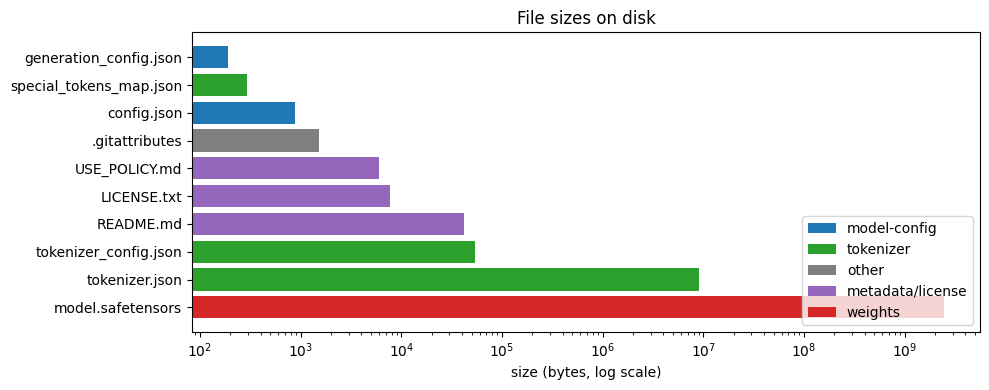

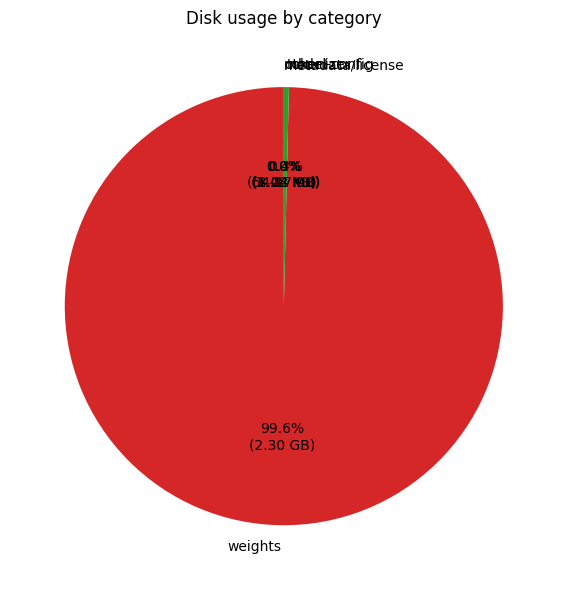


**Summary** — files: `10`, total: `2.31 GB`, fresh: `False`


In [ ]:
display(Markdown("## Part 1 — Download stage"))
display(Markdown("_Where do files land on disk? What is fetched and in what order?_"))

from huggingface_hub import snapshot_download, scan_cache_dir

def cache_info(model_id):
    try:
        for r in scan_cache_dir().repos:
            if r.repo_id == model_id:
                return True, r.size_on_disk
    except Exception: pass
    return False, 0

cached_before, size_before = cache_info(MODEL_ID)
display(Markdown(f"**Cache before:** hit=`{cached_before}`" +
                 (f", size=`{fmt_size(size_before)}`" if cached_before else "")))

with Stage("snapshot_download", reads="huggingface hub"):
    local_path = snapshot_download(repo_id=MODEL_ID)

hf_root = Path(os.path.expanduser("~/.cache/huggingface/hub"))
display(Markdown(f"""
**Cache layout**
- root: `{hf_root}`
- snapshot: `{local_path}`
- relative: `{Path(local_path).relative_to(hf_root)}`
"""))

def categorize(name):
    n = name.lower()
    if n.endswith((".safetensors", ".bin")):                return "weights"
    if n in ("config.json", "generation_config.json"):      return "model-config"
    if "tokenizer" in n or n == "special_tokens_map.json":  return "tokenizer"
    if n.endswith((".md", ".txt")):                         return "metadata/license"
    return "other"

rows = []
for f in os.listdir(local_path):
    full = os.path.join(local_path, f)
    if os.path.isfile(full) or os.path.islink(full):
        s = os.path.getsize(full)
        rows.append({"filename": f, "category": categorize(f),
                     "size_bytes": s, "size": fmt_size(s)})

df_files = pd.DataFrame(rows).sort_values("size_bytes").reset_index(drop=True)
df_files.index = range(1, len(df_files) + 1)
df_files.index.name = "#"

display(Markdown("**Files on disk (small → large = fetch order)**"))
display(df_files[["filename", "category", "size"]])

# horizontal bar — file sizes (log scale)
fig, ax = plt.subplots(figsize=(10, max(3, len(df_files) * 0.4)))
ax.barh(df_files["filename"], df_files["size_bytes"],
        color=[CATEGORY_COLORS[c] for c in df_files["category"]])
ax.set_xscale("log")
ax.set_xlabel("size (bytes, log scale)")
ax.set_title("File sizes on disk")
ax.invert_yaxis()
cats_present = df_files["category"].unique()
ax.legend(handles=[Patch(facecolor=CATEGORY_COLORS[c], label=c) for c in cats_present],
          loc="lower right")
plt.tight_layout(); plt.show()

# # pie — disk usage by category
# cat_sizes = df_files.groupby("category")["size_bytes"].sum().sort_values(ascending=False)
# fig, ax = plt.subplots(figsize=(6, 6))
# ax.pie(cat_sizes.values, labels=cat_sizes.index,
#        colors=[CATEGORY_COLORS[c] for c in cat_sizes.index],
#        autopct=lambda p: f"{p:.1f}%\n({fmt_size(p * cat_sizes.sum() / 100)})",
#        startangle=90)
# ax.set_title("Disk usage by category"); plt.tight_layout(); plt.show()

total = df_files["size_bytes"].sum()
display(Markdown(f"""
**Summary** — files: `{len(df_files)}`, total: `{fmt_size(total)}`, fresh: `{not cached_before}`
"""))

## Part 2 — Load into RAM stage

_Disk → RAM. What is read, in what order, how much memory is consumed?_

**Baseline RAM (before model load):** `415.9 MB`

▶ load tokenizer
  reads: tokenizer.json, tokenizer_config.json, special_tokens_map.json


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


  ✓ 2.20s   ΔRAM +229.8 MB   total 645.7 MB

▶ load model config
  reads: config.json
  ✓ 0.03s   ΔRAM +0.0 MB   total 645.7 MB

▶ load model weights
  reads: *.safetensors


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

  ✓ 10.36s   ΔRAM +2349.7 MB   total 2995.4 MB



**Step-by-step load log**

,stage,reads,ram_before_MB,ram_after_MB,ram_delta_MB,time_s
0,load tokenizer,"tokenizer.json, tokenizer_config.json, special...",415.9,645.7,229.8,2.20
1,load model config,config.json,645.7,645.7,0.0,0.03
2,load model weights,*.safetensors,645.7,2995.4,2349.7,10.36


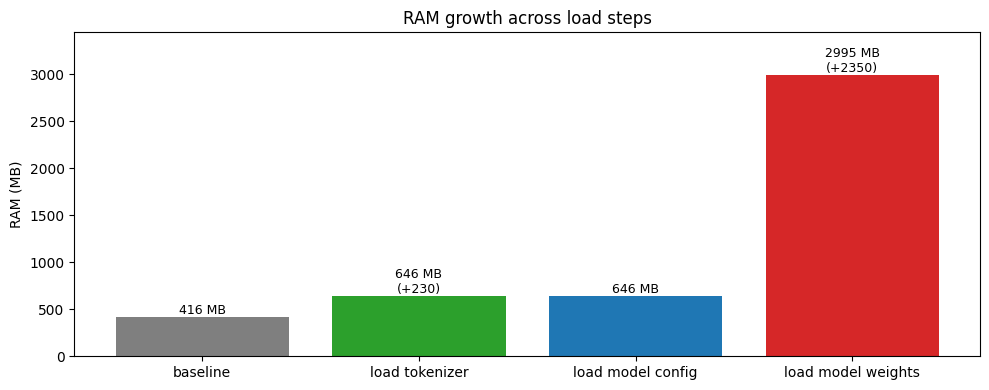

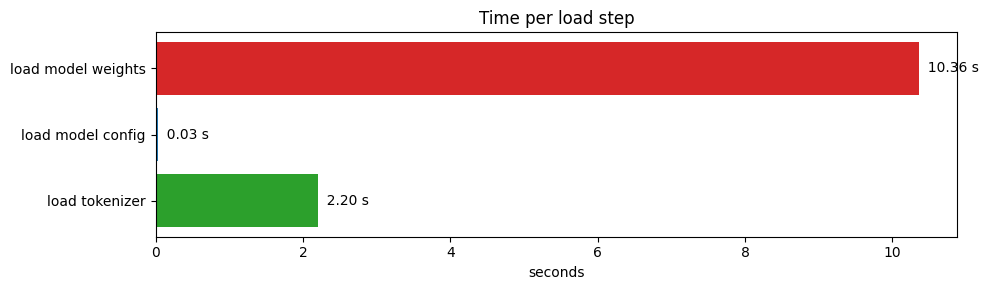


**Model summary**

| property | value |
|---|---|
| architecture     | `LlamaForCausalLM` |
| hidden size      | `2048` |
| num layers       | `16` |
| vocab size       | `128000` |
| dtype            | `torch.float16` |
| device           | `cpu` |
| total parameters | `1,235,814,400` (1.236 B) |
| theoretical size | `2.30 GB` |
| RAM by model     | `2580.8 MB` |


In [3]:
display(Markdown("## Part 2 — Load into RAM stage"))
display(Markdown("_Disk → RAM. What is read, in what order, how much memory is consumed?_"))

from transformers import AutoTokenizer, AutoConfig, AutoModelForCausalLM

ram_baseline = ram_mb()
display(Markdown(f"**Baseline RAM (before model load):** `{ram_baseline:.1f} MB`"))

log_start = len(STAGE_LOG)

with Stage("load tokenizer", reads="tokenizer.json, tokenizer_config.json, special_tokens_map.json"):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

with Stage("load model config", reads="config.json"):
    config = AutoConfig.from_pretrained(MODEL_ID)

with Stage("load model weights", reads="*.safetensors"):
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16)
    model.eval()

df_load = pd.DataFrame(STAGE_LOG[log_start:])
display(Markdown("**Step-by-step load log**"))
display(df_load)

# RAM growth bar
labels  = ["baseline"] + df_load["stage"].tolist()
values  = [ram_baseline] + df_load["ram_after_MB"].tolist()
deltas  = [0] + df_load["ram_delta_MB"].tolist()
colors  = ["#7f7f7f", "#2ca02c", "#1f77b4", "#d62728"]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, values, color=colors)
for bar, d in zip(bars, deltas):
    h = bar.get_height()
    txt = f"{h:.0f} MB" + (f"\n(+{d:.0f})" if d > 0 else "")
    ax.text(bar.get_x() + bar.get_width()/2, h, txt, ha="center", va="bottom", fontsize=9)
ax.set_ylabel("RAM (MB)"); ax.set_title("RAM growth across load steps")
ax.set_ylim(0, max(values) * 1.15)
plt.tight_layout(); plt.show()

# time per step
fig, ax = plt.subplots(figsize=(10, 3))
ax.barh(df_load["stage"], df_load["time_s"], color=["#2ca02c", "#1f77b4", "#d62728"])
for i, v in enumerate(df_load["time_s"]):
    ax.text(v, i, f"  {v:.2f} s", va="center")
ax.set_xlabel("seconds"); ax.set_title("Time per load step")
plt.tight_layout(); plt.show()

total_params = sum(p.numel() for p in model.parameters())
param_bytes  = sum(p.numel() * p.element_size() for p in model.parameters())

display(Markdown(f"""
**Model summary**

| property | value |
|---|---|
| architecture     | `{config.architectures[0] if config.architectures else 'n/a'}` |
| hidden size      | `{config.hidden_size}` |
| num layers       | `{config.num_hidden_layers}` |
| vocab size       | `{tokenizer.vocab_size}` |
| dtype            | `{next(model.parameters()).dtype}` |
| device           | `{next(model.parameters()).device}` |
| total parameters | `{total_params:,}` ({total_params / 1e9:.3f} B) |
| theoretical size | `{fmt_size(param_bytes)}` |
| RAM by model     | `{(ram_mb() - ram_baseline):.1f} MB` |
"""))

In [4]:
display(Markdown("## Part 3 — Inference (Level 0: opaque box)"))
display(Markdown("_Black box. Text in, text out. Only input/output tensors are visible._"))

text = "The capital of France is"
inputs = tokenizer(text, return_tensors="pt")
input_ids, attention_mask = inputs.input_ids, inputs.attention_mask

with Stage("model.generate (1 new token)"):
    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=1,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

output_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

df_io = pd.DataFrame([
    {"side": "INPUT",  "text": repr(text),
     "shape": str(tuple(input_ids.shape)),  "dtype": str(input_ids.dtype),
     "ndim":  input_ids.ndim,  "numel": input_ids.numel()},
    {"side": "OUTPUT", "text": repr(output_text),
     "shape": str(tuple(output_ids.shape)), "dtype": str(output_ids.dtype),
     "ndim":  output_ids.ndim, "numel": output_ids.numel()},
]).set_index("side")
display(df_io)

display(Markdown("""
**Level 0 observation:** only input and output tensors are visible. Everything inside the model is opaque.
Later levels will progressively open the box.
"""))

## Part 3 — Inference (Level 0: opaque box)

_Black box. Text in, text out. Only input/output tensors are visible._

▶ model.generate (1 new token)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  ✓ 2.05s   ΔRAM +6.6 MB   total 3005.1 MB



,text,shape,dtype,ndim,numel
side,,,,,
INPUT,'The capital of France is',"(1, 6)",torch.int64,2,6
OUTPUT,'The capital of France is Paris',"(1, 7)",torch.int64,2,7



**Level 0 observation:** only input and output tensors are visible. Everything inside the model is opaque.
Later levels will progressively open the box.


In [5]:
from IPython.display import display, Markdown
import pandas as pd
import torch

# ─────────────────────────────────────────────────────────────
# PART 3 — INFERENCE (Level 0: opaque box)
# ─────────────────────────────────────────────────────────────

display(Markdown("## Part 3 — Inference (Level 0: opaque box)"))
display(Markdown("_Black box. Text in, text out. Pipeline middle is opaque at this level — it opens progressively from Level 1 onwards._"))

# ─── run inference ───────────────────────────────────────────
text = "The capital of France is"
inputs = tokenizer(text, return_tensors="pt")
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask

with torch.no_grad():
    output_ids = model.generate(
        input_ids,
        attention_mask=attention_mask,
        max_new_tokens=1,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

output_text = tokenizer.decode(output_ids[0], skip_special_tokens=True, clean_up_tokenization_spaces=False)

# ═════════════════════════════════════════════════════════════
# PLAIN-PRINT VIEW (Pattern B — terminal-friendly, always present)
# ═════════════════════════════════════════════════════════════

print("========== INPUT ==========")
print("text  :", repr(text))
print("shape :", input_ids.shape)
print("dtype :", input_ids.dtype)
print("ndim  :", input_ids.ndim)
print("===========================")
print()

print("========== MIDDLE (opaque at Level 0) ==========")
print("step  : model.generate(...)")
print("op    : opaque")
print("in    :", tuple(input_ids.shape), str(input_ids.dtype))
print("out   :", tuple(output_ids.shape), str(output_ids.dtype))
print("note  : internals hidden — opens progressively from Level 1 onwards")
print("================================================")
print()

print("========== OUTPUT ==========")
print("text  :", repr(output_text))
print("shape :", output_ids.shape)
print("dtype :", output_ids.dtype)
print("ndim  :", output_ids.ndim)
print("============================")

# ═════════════════════════════════════════════════════════════
# RICH-DISPLAY VIEW (Pattern A — DataFrames, grows each level)
# ═════════════════════════════════════════════════════════════

display(Markdown("---"))
display(Markdown("### Rich view"))

# INPUT / OUTPUT table
display(Markdown("**Input and Output tensors**"))
df_io = pd.DataFrame([
    {
        "side":  "INPUT",
        "text":  repr(text),
        "shape": str(tuple(input_ids.shape)),
        "dtype": str(input_ids.dtype),
        "ndim":  input_ids.ndim,
        "numel": input_ids.numel(),
    },
    {
        "side":  "OUTPUT",
        "text":  repr(output_text),
        "shape": str(tuple(output_ids.shape)),
        "dtype": str(output_ids.dtype),
        "ndim":  output_ids.ndim,
        "numel": output_ids.numel(),
    },
]).set_index("side")
display(df_io)

# PIPELINE table — at Level 0 it has 1 opaque row.
# At later levels we append rows (tokenize, embed, blocks, LM head, pick, decode).
display(Markdown("**Pipeline (middle) — at Level 0 this is one opaque step. Rows will grow each level.**"))
pipeline_rows = [
    {
        "step":           "model.generate",
        "op":             "opaque",
        "in_shape":       str(tuple(input_ids.shape)),
        "in_dtype":       str(input_ids.dtype),
        "out_shape":      str(tuple(output_ids.shape)),
        "out_dtype":      str(output_ids.dtype),
        "static_weights": "{model}  (vocab + all learned weights, bundled)",
        "dim_out":        "scalar (1 new token id)",
    },
]
df_pipeline = pd.DataFrame(pipeline_rows)
df_pipeline.index = range(1, len(df_pipeline) + 1)
df_pipeline.index.name = "#"
display(df_pipeline)

display(Markdown(f"""
**Level 0 observation**

- Input and output tensors are visible.
- Everything between them is one opaque step: `model.generate`.
- The pipeline table has **1 row** today. By Level 49 it will have dozens of rows
  (tokenize → embed → N transformer blocks → final norm → LM head → softmax → argmax → decode).
- Both views are kept on purpose:
  - **plain-print view** stays terminal-friendly and easy to diff between levels
  - **rich view (DataFrames)** scales to attention heatmaps, logit distributions, embedding plots in later levels
"""))

## Part 3 — Inference (Level 0: opaque box)

_Black box. Text in, text out. Pipeline middle is opaque at this level — it opens progressively from Level 1 onwards._

========== INPUT ==========
text  : 'The capital of France is'
shape : torch.Size([1, 6])
dtype : torch.int64
ndim  : 2

========== MIDDLE (opaque at Level 0) ==========
step  : model.generate(...)
op    : opaque
in    : (1, 6) torch.int64
out   : (1, 7) torch.int64
note  : internals hidden — opens progressively from Level 1 onwards

========== OUTPUT ==========
text  : 'The capital of France is Paris'
shape : torch.Size([1, 7])
dtype : torch.int64
ndim  : 2


---

### Rich view

**Input and Output tensors**

,text,shape,dtype,ndim,numel
side,,,,,
INPUT,'The capital of France is',"(1, 6)",torch.int64,2,6
OUTPUT,'The capital of France is Paris',"(1, 7)",torch.int64,2,7


**Pipeline (middle) — at Level 0 this is one opaque step. Rows will grow each level.**

,step,op,in_shape,in_dtype,out_shape,out_dtype,static_weights,dim_out
#,,,,,,,,
1,model.generate,opaque,"(1, 6)",torch.int64,"(1, 7)",torch.int64,"{model} (vocab + all learned weights, bundled)",scalar (1 new token id)



**Level 0 observation**

- Input and output tensors are visible.
- Everything between them is one opaque step: `model.generate`.
- The pipeline table has **1 row** today. By Level 49 it will have dozens of rows
  (tokenize → embed → N transformer blocks → final norm → LM head → softmax → argmax → decode).
- Both views are kept on purpose:
  - **plain-print view** stays terminal-friendly and easy to diff between levels
  - **rich view (DataFrames)** scales to attention heatmaps, logit distributions, embedding plots in later levels
